In [2]:
import copy
import random
import numpy as np
import pandas as pd
import torch


In [3]:
import sys
sys.path.append("../src/")

%load_ext autoreload
%autoreload 2
# Importing our custom module(s)
import approximate_posteriors
import layers
import utils


In [4]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)


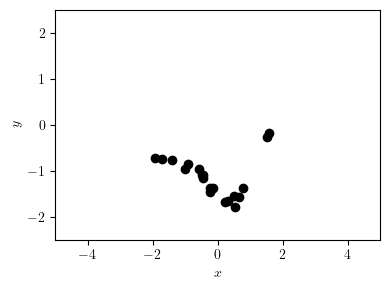

In [5]:
N = 20
D = 1
X_numpy = np.random.randn(N, D)
K = utils.rbf_kernel(X_numpy, X_numpy, lengthscale=1.0, outputscale=1.0)
#K = utils.matern_kernel(X_numpy, X_numpy, lengthscale=1.0, nu=2.5, outputscale=1.0)
#y_numpy = np.sin(3 * np.sum(X_numpy, axis=1, keepdims=True)) + 0.1 * np.random.randn(N, 1)
y_numpy = np.random.multivariate_normal(mean=np.zeros(N), cov=K, size=1).reshape(N, 1) + 0.1 * np.random.randn(N, 1)

X = torch.tensor(X_numpy.reshape(-1, 1), dtype=torch.float64)
y = torch.tensor(y_numpy.reshape(-1, 1), dtype=torch.float64)

ncols, nrows = 1, 1
fig, ax = plt.subplots(figsize=(4*ncols, 3*nrows), ncols=ncols, nrows=nrows)

ax.scatter(X_numpy, y_numpy, color="#000000")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_xlim([-5, 5])
ax.set_ylim([-2.5, 2.5])

fig.tight_layout()
plt.show()


In [6]:
phi = layers.RBFRFFs(D=1, learnable_lengthscale=False, learnable_outputscale=False, lengthscale=1.0, outputscale=1.0, R=1_024)
init_state_dict = copy.deepcopy(phi.state_dict())


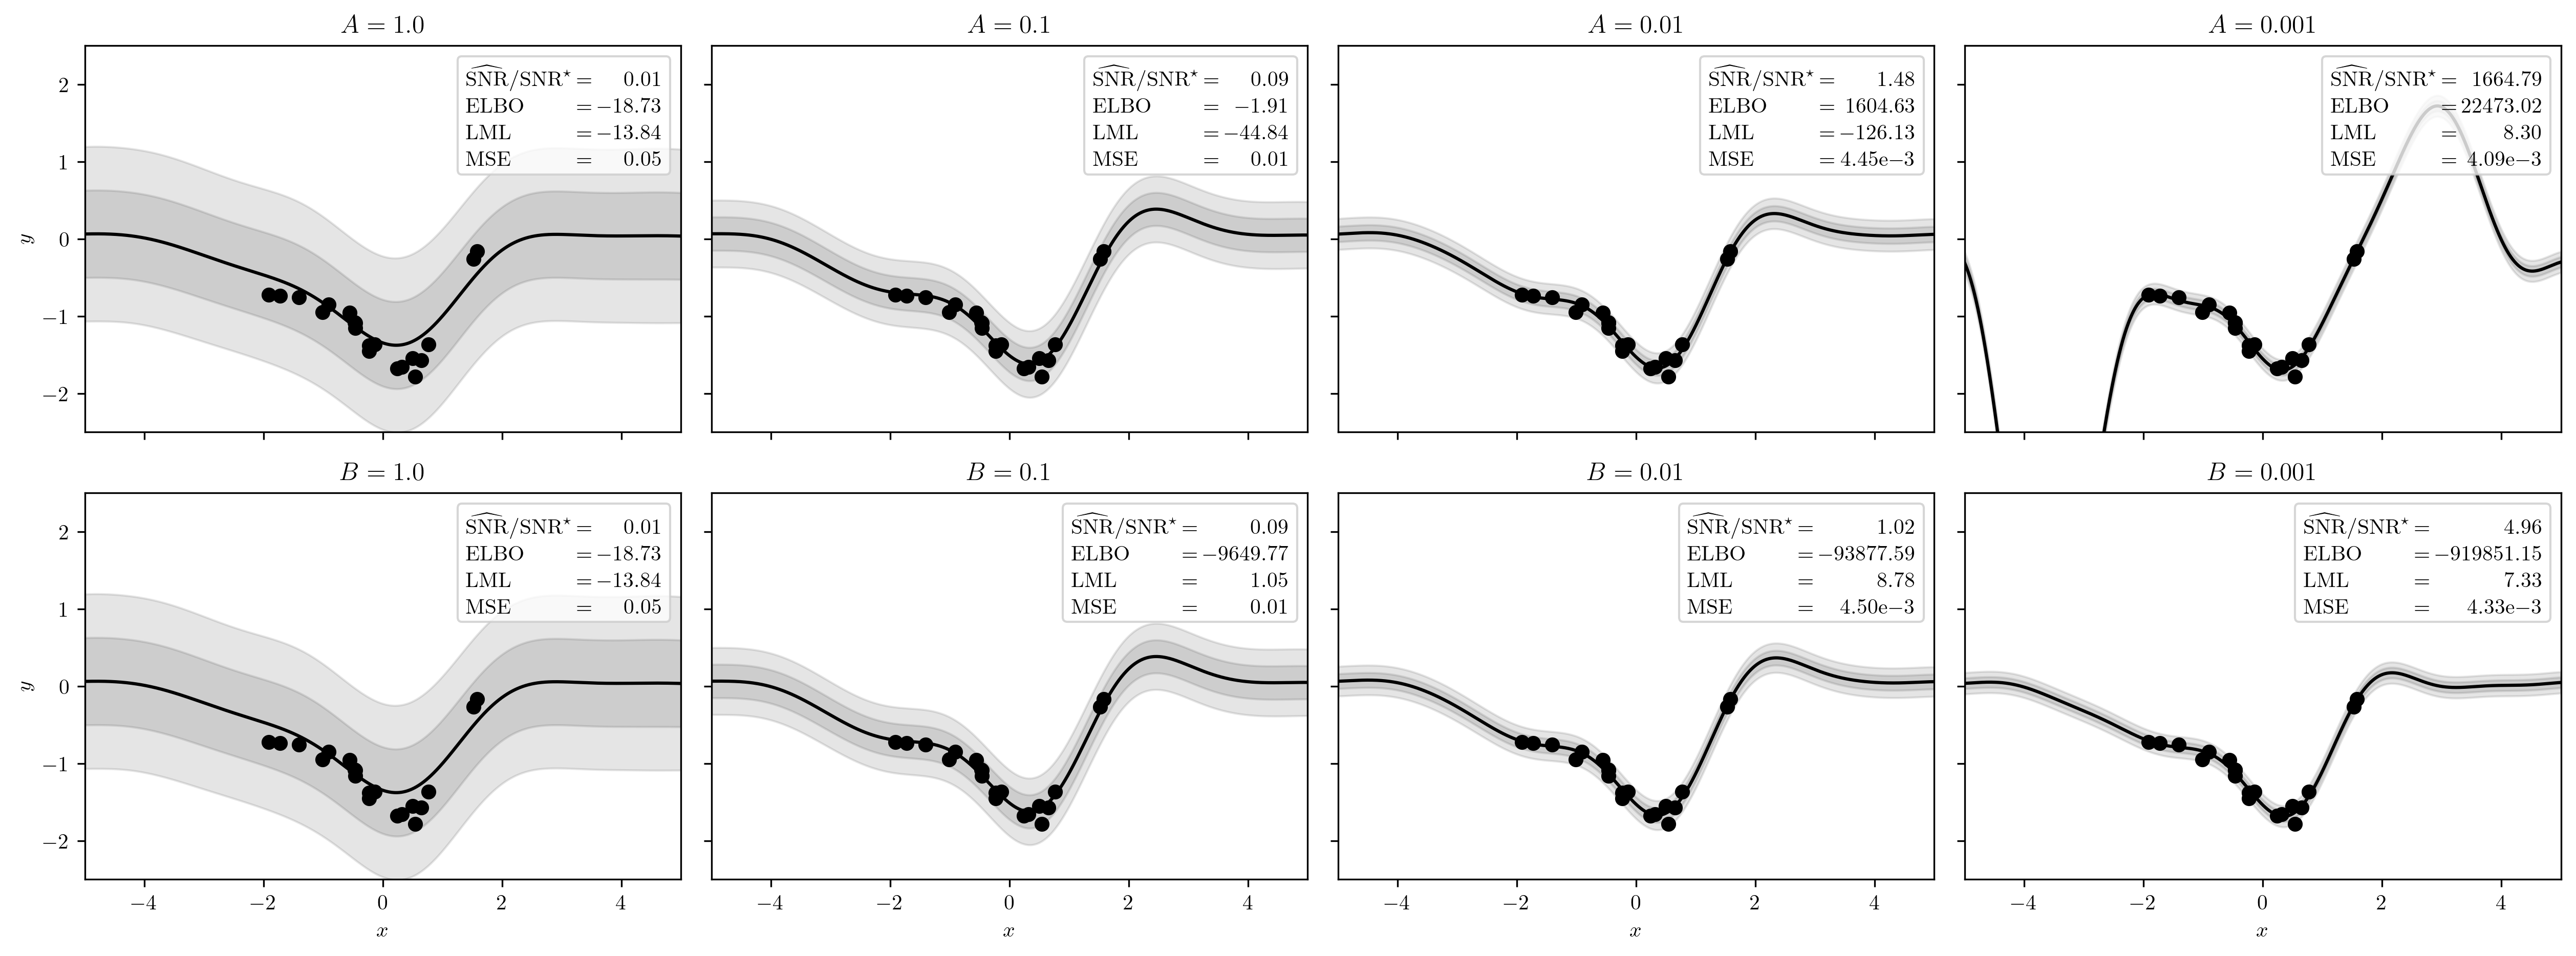

In [7]:
def format_number(x, precision=2):
    if abs(x) < 0.005:
        mantissa, exp = f"{x:.{precision}e}".split("e")
        exp = int(exp)
        return rf"\mathrm{{{mantissa}e{exp}}}".replace("-", "{-}")
    else:
        return rf"\mathrm{{{x:.{precision}f}}}"

linspace = np.linspace(start=-5, stop=5, num=1_000)

ncols, nrows = 4, 2
zoom = 2.5
latex_width_pts = 487.8225
inches_per_pt = 1.0 / 72.27
figure_width_inches = latex_width_pts * inches_per_pt
figure_height_inches = (3 / 4) * (nrows / ncols) * figure_width_inches

fig, axs = plt.subplots(dpi=300, figsize=(zoom * figure_width_inches, zoom * figure_height_inches), ncols=ncols, nrows=nrows, sharex="col", sharey="row")

for i, temp in enumerate([1.0, 0.1, 0.01, 0.001]):

    phi = layers.RBFRFFs(D=1, learnable_lengthscale=False, learnable_outputscale=False, lengthscale=1.0, outputscale=1.0, R=1_024)
    phi.load_state_dict(init_state_dict)
    model = approximate_posteriors.DiagonalCovariance(
        m = None,
        s = None,
        sigma_f = torch.tensor([1.0], dtype=torch.float64),
        sigma_n2 = torch.tensor([1.0], dtype=torch.float64),
        tau = torch.tensor([1.0], dtype=torch.float64),
        temp = torch.tensor([temp], dtype=torch.float64),
        cold = torch.tensor([1.0], dtype=torch.float64),
    )
    elbos, lmls, best_checkpoint = utils.cavi(X, y, phi, model)
    
    with torch.no_grad():

        phi.load_state_dict(best_checkpoint["phi"])
        model.load_state_dict(best_checkpoint["model"])

        Phi = phi(X)
        snr = ((1.0 ** 2 * torch.sum(Phi ** 2)) / (N * 0.1 ** 2)).item()
        diagonal_snr = ((model.sigma_f ** 2 * torch.sum(Phi ** 2)) / (N * model.temp * model.sigma_n2)).item()
        diagonal_relative_snr = diagonal_snr / snr

        idx = np.argmax(elbos)
        diagonal_elbo = elbos[idx]
        diagonal_lml = lmls[idx]
        diagonal_mse = torch.nn.functional.mse_loss(model.sigma_f * Phi @ model.m, y)

        X_star = torch.linspace(start=-5, end=5, steps=1_000, dtype=torch.float64).view(-1, 1)
        Phi_star = phi(X_star)
        diagonal_mean = model.sigma_f * Phi_star @ model.m
        diagonal_var_f = (model.sigma_f ** 2) * torch.sum((Phi_star @ model.covariance()) * Phi_star, dim=1, keepdim=True)
        diagonal_var_y = diagonal_var_f + model.sigma_n2

    axs[0,i].scatter(X_numpy, y_numpy, color="#000000")
    axs[0,i].fill_between(linspace, diagonal_mean.squeeze() + 2 * torch.sqrt(diagonal_var_y).squeeze(), diagonal_mean.squeeze() - 2 * torch.sqrt(diagonal_var_y).squeeze(), alpha=0.1, color="#000000")
    axs[0,i].fill_between(linspace, diagonal_mean.squeeze() + 1 * torch.sqrt(diagonal_var_y).squeeze(), diagonal_mean.squeeze() - 1 * torch.sqrt(diagonal_var_y).squeeze(), alpha=0.1, color="#000000")
    axs[0,i].plot(linspace, diagonal_mean.squeeze(), color="#000000")
    axs[0,i].plot([], [], " ", label=(
        r"$\begin{array}{l@{\,}c@{\,}r}"
        rf"\widehat{{\mathrm{{SNR}}}}/\mathrm{{SNR}}^\star &=& {diagonal_relative_snr:.2f} \\"
        rf"\mathrm{{ELBO}} &=& {format_number(diagonal_elbo)} \\"
        rf"\mathrm{{LML}} &=& {format_number(diagonal_lml)} \\"
        rf"\mathrm{{MSE}} &=& {format_number(diagonal_mse)} \\"
        r"\end{array}$"
    ))
    axs[0,i].set_title(rf"$A={temp}$")
    axs[0,i].set_xlim([-5, 5])
    axs[0,i].set_ylim([-2.5, 2.5])
    axs[0,i].legend(loc="upper right", handlelength=0, handletextpad=0)

axs[0,0].set_ylabel(r"$y$")

for i, cold in enumerate([1.0, 0.1, 0.01, 0.001]):

    phi = layers.RBFRFFs(D=1, learnable_lengthscale=False, learnable_outputscale=False, lengthscale=1.0, outputscale=1.0, R=1_024)
    phi.load_state_dict(init_state_dict)
    model = approximate_posteriors.DiagonalCovariance(
        m = None,
        s = None,
        sigma_f = torch.tensor([1.0], dtype=torch.float64),
        sigma_n2 = torch.tensor([1.0], dtype=torch.float64),
        tau = torch.tensor([1.0], dtype=torch.float64),
        temp = torch.tensor([1.0], dtype=torch.float64),
        cold = torch.tensor([cold], dtype=torch.float64),
    )
    elbos, lmls, best_checkpoint = utils.cavi(X, y, phi, model)
    
    with torch.no_grad():

        phi.load_state_dict(best_checkpoint["phi"])
        model.load_state_dict(best_checkpoint["model"])

        Phi = phi(X)
        snr = ((1.0 ** 2 * torch.sum(Phi ** 2)) / (N * 0.1 ** 2)).item()
        diagonal_snr = ((model.sigma_f ** 2 * torch.sum(Phi ** 2)) / (N * model.temp * model.sigma_n2)).item()
        diagonal_relative_snr = diagonal_snr / snr

        idx = np.argmax(elbos)
        diagonal_elbo = elbos[idx]
        diagonal_lml = lmls[idx]
        diagonal_mse = torch.nn.functional.mse_loss(model.sigma_f * Phi @ model.m, y)

        X_star = torch.linspace(start=-5, end=5, steps=1_000, dtype=torch.float64).view(-1, 1)
        Phi_star = phi(X_star)
        diagonal_mean = model.sigma_f * Phi_star @ model.m
        diagonal_var_f = (model.sigma_f ** 2) * torch.sum((Phi_star @ model.covariance()) * Phi_star, dim=1, keepdim=True)
        diagonal_var_y = diagonal_var_f + model.sigma_n2

    axs[1,i].scatter(X_numpy, y_numpy, color="#000000")
    axs[1,i].fill_between(linspace, diagonal_mean.squeeze() + 2 * torch.sqrt(diagonal_var_y).squeeze(), diagonal_mean.squeeze() - 2 * torch.sqrt(diagonal_var_y).squeeze(), alpha=0.1, color="#000000")
    axs[1,i].fill_between(linspace, diagonal_mean.squeeze() + 1 * torch.sqrt(diagonal_var_y).squeeze(), diagonal_mean.squeeze() - 1 * torch.sqrt(diagonal_var_y).squeeze(), alpha=0.1, color="#000000")
    axs[1,i].plot(linspace, diagonal_mean.squeeze(), color="#000000")
    axs[1,i].plot([], [], " ", label=(
        r"$\begin{array}{l@{\,}c@{\,}r}"
        rf"\widehat{{\mathrm{{SNR}}}}/\mathrm{{SNR}}^\star &=& {diagonal_relative_snr:.2f} \\"
        rf"\mathrm{{ELBO}} &=& {format_number(diagonal_elbo)} \\"
        rf"\mathrm{{LML}} &=& {format_number(diagonal_lml)} \\"
        rf"\mathrm{{MSE}} &=& {format_number(diagonal_mse)} \\"
        r"\end{array}$"
    ))
    axs[1,i].set_title(rf"$B={cold}$")
    axs[1,i].set_xlabel(r"$x$")
    axs[1,i].set_xlim([-5, 5])
    axs[1,i].set_ylim([-2.5, 2.5])
    axs[1,i].legend(loc="upper right", handlelength=0, handletextpad=0)

axs[1,0].set_ylabel(r"$y$")

fig.tight_layout()
fig.savefig("tempered_likelihood_and_joint.pdf", bbox_inches="tight")
plt.show()
